# The Weekend Effect 📆
### Are Mondays really negative, and does buying Tuesday beat the market?

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Weekend effect still there?: Busted](https://img.shields.io/badge/Weekend_effect_still_there%3F-Busted-8b949e?style=flat-square)

For decades the folklore has said the market falls over the weekend — a *negative Monday* — and bounces on *turnaround Tuesday*, so you should avoid Monday and buy Tuesday. We measure the average return on each weekday of SPY (dividends included) and ask the only two questions that matter: is the pattern **really there** (barely, and not the part everyone repeats), and could you **trade it** (no).

> 📓 **This is the plain-language layer.** The HAC *t*-stats, the five-test selection problem and the pre/post-2000 split are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** Educational, reproducible research — every chart below is generated by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study root (weekend/)
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from weekend import data, strategy

AS_OF = "2026-06-12"
frame = data.load_real("SPY", mode="total_return").loc[:AS_OF]
close = frame["close"]
wm = strategy.weekday_means(close)
bh = strategy.buy_and_hold(close)
tue_only = strategy.backtest(close, strategy.tuesday_only_position(close), cost_bps=1.0)
skip_mon = strategy.backtest(close, strategy.skip_monday_position(close), cost_bps=1.0)
print(f"SPY total return: {len(close):,} rows  {close.index[0].date()} -> {close.index[-1].date()}  fingerprint={data.fingerprint(frame)}")
print(wm.round(2))


SPY total return: 8,400 rows  1993-01-29 -> 2026-06-12  fingerprint=c68e7ea2802e
     mean_bps         n  hac_t
Mon     5.640 1,578.000  2.060
Tue     7.170 1,725.000  2.640
Wed     6.200 1,723.000  2.210
Thu     1.460 1,690.000  0.520
Fri     3.320 1,683.000  1.330


## The answer first 🎯

| Question | Answer |
|---|---|
| Is Monday negative (the weekend effect)? | **No** — Monday averages **+5.64 bps**, *positive*. The famous part of the story isn't in the data. |
| Does Tuesday beat the other days? | **A little** — Tuesday is the best weekday (+7.17 bps), but only **+3.03 bps** more than the rest, which isn't statistically convincing. |
| Can you trade it? | **No** — "buy Tuesday" earns **2.36%/yr** vs **10.82%/yr** for just holding — about **8 points/yr less**, because you sit in cash four days out of five. |

## 1 · The claim

*"Mondays are negative — the **weekend effect** — and Tuesday rebounds (**turnaround Tuesday**). Avoid Monday / buy Tuesday and you beat buy-and-hold."* It really was true once: Kenneth French's 1980 paper found significantly negative Mondays on 1953–1977 index data. The question is whether it's still true today.

## 2 · So what?

If a calendar this simple beat the market, you'd just trade the days of the week and ignore everything else. And if a *published* anomaly quietly disappears once everyone knows it, that tells you something deep about how markets absorb information. Both are worth checking honestly rather than repeating the slogan.

## 3 · How would we even know?

We take SPY (dividends included), 1993 to today, and average the daily return on each weekday. Then we line Tuesday and Monday up against *all the other days*. Finally we build the two literal rules — **buy only on Tuesday** and **skip Monday** — and race them against simply holding SPY, paying **1 bp** every time we switch in or out. If the pattern is real and tradable, a rule should win. If it's a leftover slogan, it won't.

## 4 · The teardown — let's actually look

First, the average return on each weekday.

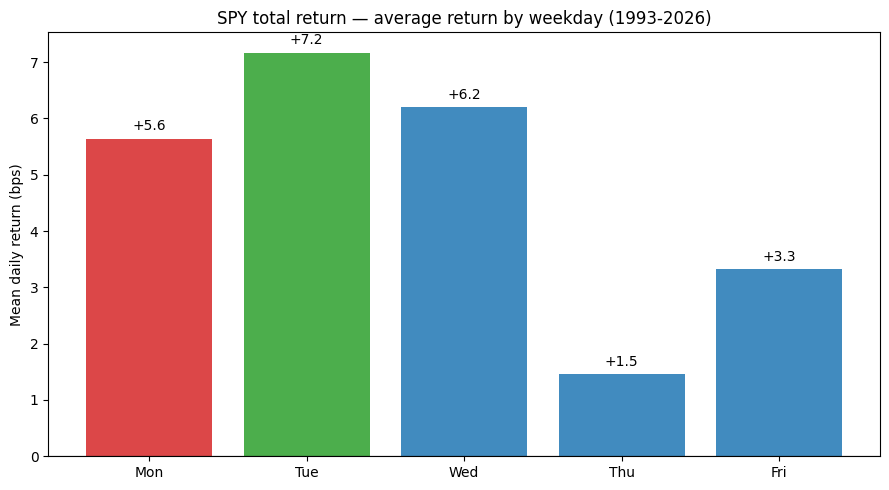

In [2]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['C3' if d=='Mon' else ('C2' if d=='Tue' else 'C0') for d in wm.index]
ax.bar(wm.index, wm['mean_bps'], color=colors, alpha=.85)
ax.axhline(0, color='k', lw=.8)
for d, v in wm['mean_bps'].items():
    ax.text(d, v + .15, f'{v:+.1f}', ha='center', fontsize=10)
ax.set_ylabel('Mean daily return (bps)'); ax.set_title('SPY total return — average return by weekday (1993-2026)')
plt.tight_layout(); plt.show()

**Monday is the third-best day, not a negative one** (+5.64 bps). Tuesday *is* the tallest bar (+7.17 bps) — the folklore got the *direction* of turnaround Tuesday right — but every weekday's average is positive. The defining feature of the weekend effect, a down-Monday, simply isn't here.

Now the only test that matters for trading: do the literal rules beat just holding SPY?

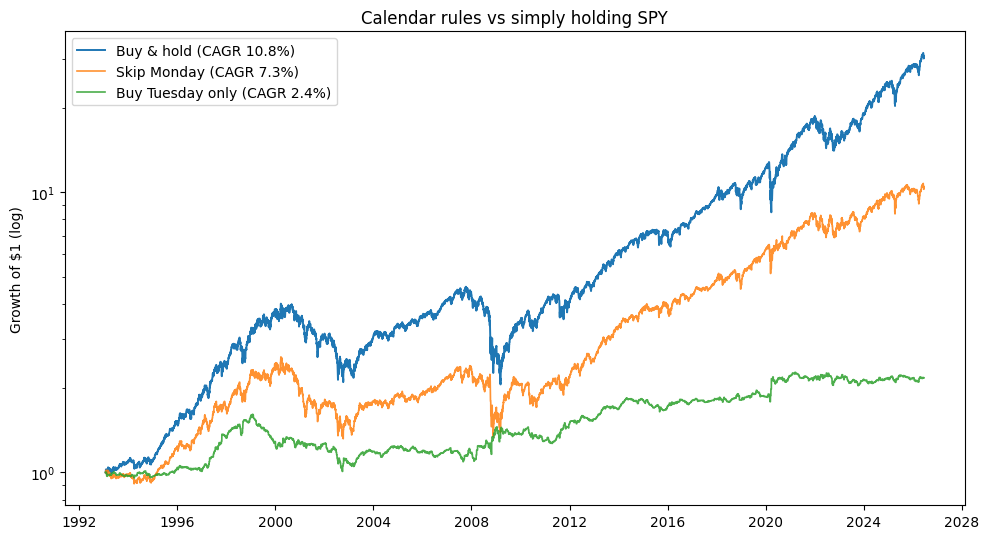

In [3]:
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(bh['equity'], label=f"Buy & hold (CAGR {bh['cagr']*100:.1f}%)", lw=1.4)
ax.plot(skip_mon['equity'], label=f"Skip Monday (CAGR {skip_mon['cagr']*100:.1f}%)", lw=1.2, alpha=.85)
ax.plot(tue_only['equity'], label=f"Buy Tuesday only (CAGR {tue_only['cagr']*100:.1f}%)", lw=1.2, alpha=.85)
ax.set_yscale('log'); ax.set_ylabel('Growth of $1 (log)'); ax.legend()
ax.set_title('Calendar rules vs simply holding SPY'); plt.tight_layout(); plt.show()

It isn't close. **Buy-Tuesday ends far below buy-and-hold** (2.36% vs 10.82% a year) because it's in cash ~79% of the time and misses the upward drift on every other day. **Skip-Monday** does better but still trails by ~4 points/yr. You can't beat the market by sitting out part of it.

## 5 · The verdict

- **Weekend effect still there? → Busted.** Monday is *positive* (+5.64 bps), not negative — across the whole record, before and after 2000.
- **Signal → Weak.** Tuesday is the best day but only +3.03 bps above the rest, which isn't statistically convincing once you remember you're testing five days.
- **Trade it? → Mirage.** Every literal rule loses to buy-and-hold by 4–8 points a year.

## 6 · Could you actually trade it?

Mechanically, yes — it's just SPY on a calendar, infinitely liquid. The problem is economic: a weekday rule keeps you out of the market on the days it doesn't favour, and the equity premium you forfeit on those days **dwarfs** any weekday tilt. As *"a calendar that beats the index,"* it's a mirage — and that's before taxes on thousands of switches.

## 7 · Going further 🚪

- Does the weekend effect survive on a **longer, pre-1993** index (price-only `^GSPC` back to the 1950s)? That's the window French studied — fork it and check.
- Other calendar lore: turn-of-the-month, the Santa-Claus rally, sell-in-May.
- Is there a *Monday-after-a-down-Friday* conditional effect hiding inside the flat unconditional Monday? Test it (with a Wilson interval on the conditional mean).